# Intern Performance Prediction Using Machine Learning

## Objective

The objective of this project is to predict intern performance based on attendance, task completion, mentor feedback, learning hours, and engagement using Machine Learning.

The project uses Python, Pandas, NumPy, Matplotlib, and Scikit-learn to build a predictive model that helps mentors identify interns who may need additional support.# Intern Performance Prediction Using Machine Learning


In [1]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Display Settings
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


## Generate Internship Dataset

A synthetic dataset of 1000 internship records is generated to simulate real-world intern performance data. The dataset includes attendance, task completion, mentor feedback, learning hours, engagement, and overall performance.

In [2]:
# ============================================
# Generate Internship Dataset
# ============================================

import random

np.random.seed(42)
random.seed(42)

n = 1000

attendance = np.random.randint(50, 101, n)
tasks_completed = np.random.randint(5, 31, n)
task_score = np.random.randint(50, 101, n)
mentor_feedback = np.random.randint(1, 6, n)
meetings_attended = np.random.randint(1, 11, n)
learning_hours = np.random.randint(10, 101, n)
deadlines_missed = np.random.randint(0, 6, n)

performance = []

for i in range(n):

    score = (
        attendance[i]*0.30 +
        task_score[i]*0.35 +
        mentor_feedback[i]*8 +
        learning_hours[i]*0.20 +
        tasks_completed[i]*0.70 -
        deadlines_missed[i]*6
    )

    if score >= 90:
        performance.append("High")
    elif score >= 70:
        performance.append("Medium")
    else:
        performance.append("Low")

df = pd.DataFrame({

    "Intern_ID":[f"INT{1001+i}" for i in range(n)],
    "Attendance (%)":attendance,
    "Tasks Completed":tasks_completed,
    "Average Task Score":task_score,
    "Mentor Feedback":mentor_feedback,
    "Meetings Attended":meetings_attended,
    "Learning Hours":learning_hours,
    "Deadlines Missed":deadlines_missed,
    "Performance":performance

})

df.to_csv("Intern_Performance_Dataset.csv", index=False)

print("Dataset Created Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Created Successfully!
Shape: (1000, 9)


,Intern_ID,Attendance (%),Tasks Completed,Average Task Score,Mentor Feedback,Meetings Attended,Learning Hours,Deadlines Missed,Performance
0,INT1001,88,13,57,5,2,29,0,High
1,INT1002,78,17,70,1,9,59,0,Medium
2,INT1003,64,22,67,3,8,42,1,Medium
3,INT1004,92,19,79,3,8,68,4,Medium
4,INT1005,57,8,67,5,7,52,3,Medium


## Dataset Overview and Data Cleaning

Before building a machine learning model, it is important to understand the dataset structure, identify missing values, check duplicate records, and ensure the data is clean for analysis.

In [4]:
# ============================================
# Dataset Overview
# ============================================

print("First 5 Records")
display(df.head())


First 5 Records


,Intern_ID,Attendance (%),Tasks Completed,Average Task Score,Mentor Feedback,Meetings Attended,Learning Hours,Deadlines Missed,Performance
0,INT1001,88,13,57,5,2,29,0,High
1,INT1002,78,17,70,1,9,59,0,Medium
2,INT1003,64,22,67,3,8,42,1,Medium
3,INT1004,92,19,79,3,8,68,4,Medium
4,INT1005,57,8,67,5,7,52,3,Medium


In [5]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(1000, 9)


In [6]:
print("\nColumn Names")
print(df.columns.tolist())


Column Names
['Intern_ID', 'Attendance (%)', 'Tasks Completed', 'Average Task Score', 'Mentor Feedback', 'Meetings Attended', 'Learning Hours', 'Deadlines Missed', 'Performance']


In [7]:

print("\nData Types")
display(df.dtypes)



Data Types


Intern_ID             object
Attendance (%)         int32
Tasks Completed        int32
Average Task Score     int32
Mentor Feedback        int32
Meetings Attended      int32
Learning Hours         int32
Deadlines Missed       int32
Performance           object
dtype: object

In [8]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Intern_ID           1000 non-null   object
 1   Attendance (%)      1000 non-null   int32 
 2   Tasks Completed     1000 non-null   int32 
 3   Average Task Score  1000 non-null   int32 
 4   Mentor Feedback     1000 non-null   int32 
 5   Meetings Attended   1000 non-null   int32 
 6   Learning Hours      1000 non-null   int32 
 7   Deadlines Missed    1000 non-null   int32 
 8   Performance         1000 non-null   object
dtypes: int32(7), object(2)
memory usage: 43.1+ KB


In [9]:
# ============================================
# Missing Values
# ============================================

print("Missing Values in Each Column")

missing = df.isnull().sum()

display(missing)

print("\nTotal Missing Values:", missing.sum())

Missing Values in Each Column


Intern_ID             0
Attendance (%)        0
Tasks Completed       0
Average Task Score    0
Mentor Feedback       0
Meetings Attended     0
Learning Hours        0
Deadlines Missed      0
Performance           0
dtype: int64


Total Missing Values: 0


In [10]:
# ============================================
# Duplicate Records
# ============================================

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

if duplicates == 0:
    print("Dataset is clean. No duplicate records found.")
else:
    df.drop_duplicates(inplace=True)
    print("Duplicates Removed Successfully.")

Duplicate Records: 0
Dataset is clean. No duplicate records found.


In [11]:
# ============================================
# Final Dataset Shape
# ============================================

print("Final Dataset Shape")

print(df.shape)

Final Dataset Shape
(1000, 9)


## Descriptive Statistics

Descriptive statistics provide a summary of the dataset by calculating important statistical measures such as mean, standard deviation, minimum, maximum, and quartiles. This helps in understanding the distribution of numerical features before performing visualization and machine learning.

In [12]:
# ============================================
# Descriptive Statistics
# ============================================

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

display(df.describe())

print("\nSummary Statistics Generated Successfully!")

DESCRIPTIVE STATISTICS


,Attendance (%),Tasks Completed,Average Task Score,Mentor Feedback,Meetings Attended,Learning Hours,Deadlines Missed
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,75.232000,17.37000,74.776000,3.032000,5.506000,55.609000,2.514000
std,14.651513,7.57499,14.665637,1.420913,2.892807,26.071821,1.720105
min,50.000000,5.00000,50.000000,1.000000,1.000000,10.000000,0.000000
25%,63.000000,11.00000,62.000000,2.000000,3.000000,32.000000,1.000000
50%,75.000000,17.00000,74.000000,3.000000,6.000000,56.000000,2.000000
75%,87.000000,24.00000,87.000000,4.000000,8.000000,78.000000,4.000000
max,100.000000,30.00000,100.000000,5.000000,10.000000,100.000000,5.000000



Summary Statistics Generated Successfully!


In [13]:
# ============================================
# Statistical Summary (Transpose View)
# ============================================

summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Attendance (%),1000.0,75.232,14.651513,50.0,63.0,75.0,87.0,100.0
Tasks Completed,1000.0,17.370,7.574990,5.0,11.0,17.0,24.0,30.0
Average Task Score,1000.0,74.776,14.665637,50.0,62.0,74.0,87.0,100.0
Mentor Feedback,1000.0,3.032,1.420913,1.0,2.0,3.0,4.0,5.0
Meetings Attended,1000.0,5.506,2.892807,1.0,3.0,6.0,8.0,10.0
Learning Hours,1000.0,55.609,26.071821,10.0,32.0,56.0,78.0,100.0
Deadlines Missed,1000.0,2.514,1.720105,0.0,1.0,2.0,4.0,5.0


In [14]:
# ============================================
# Performance Distribution
# ============================================

print("Performance Distribution")

display(df["Performance"].value_counts())

print("\nPercentage Distribution")

display(round(df["Performance"].value_counts(normalize=True)*100,2))

Performance Distribution


Performance
Medium    388
High      324
Low       288
Name: count, dtype: int64


Percentage Distribution


Performance
Medium    38.8
High      32.4
Low       28.8
Name: proportion, dtype: float64

## Performance Distribution

This visualization shows the number of interns in each performance category (High, Medium, and Low). It provides an overview of the target variable distribution used for machine learning.

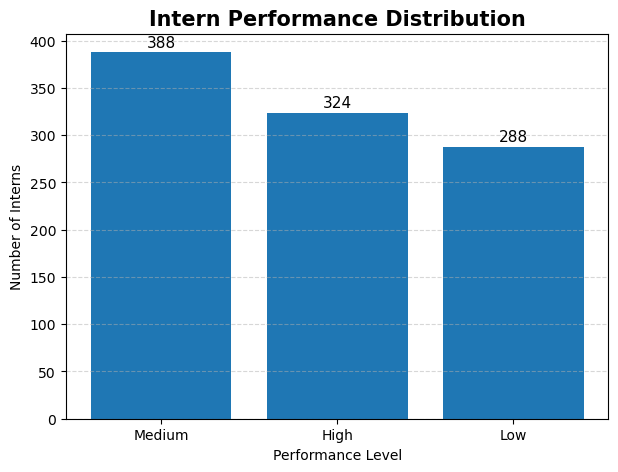

In [15]:
# ============================================
# Graph 1: Performance Distribution
# ============================================

performance_counts = df["Performance"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    performance_counts.index,
    performance_counts.values
)

plt.title("Intern Performance Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Performance Level")
plt.ylabel("Number of Interns")

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center',
        fontsize=11
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

Most interns fall into the Medium performance category, while fewer interns achieve High performance. This indicates that there is room for improvement through better engagement, mentor guidance, and consistent task completion.

## Attendance Distribution

This histogram illustrates the distribution of interns' attendance percentages. It helps identify attendance patterns and shows whether most interns maintain high, moderate, or low attendance during the internship.

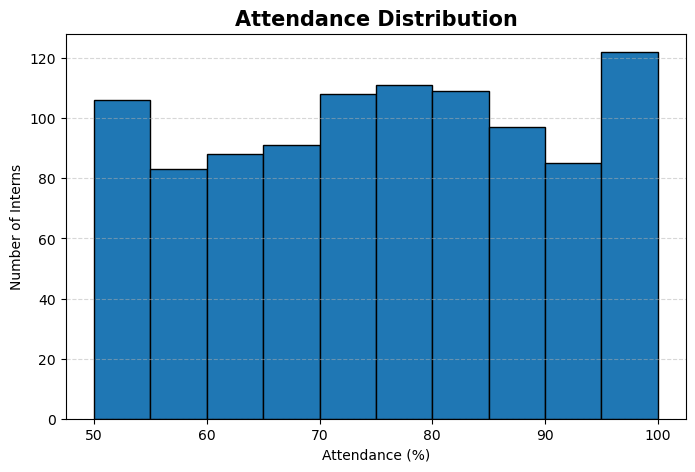

In [16]:
# ============================================
# Graph 2: Attendance Distribution
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Attendance (%)"],
    bins=10,
    edgecolor='black'
)

plt.title("Attendance Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Interns")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

The attendance distribution shows that most interns maintain moderate to high attendance. Higher attendance generally indicates better engagement and is expected to contribute positively to overall intern performance.

## Tasks Completed Distribution

This visualization shows how many tasks interns completed during the internship. It helps evaluate intern productivity and overall engagement with assigned work.

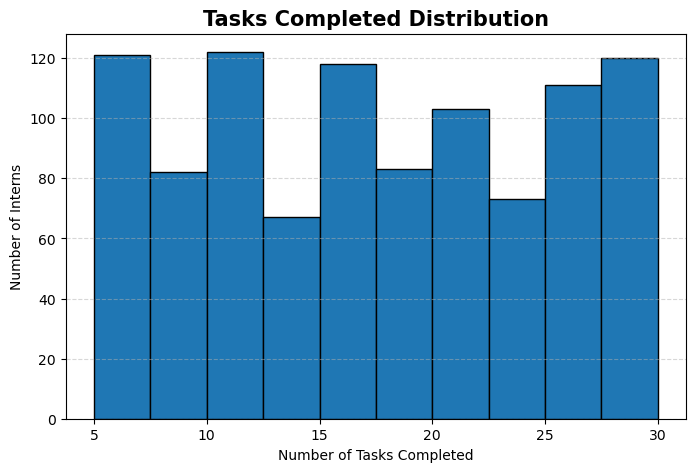

In [17]:
# ============================================
# Graph 3: Tasks Completed Distribution
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Tasks Completed"],
    bins=10,
    edgecolor='black'
)

plt.title("Tasks Completed Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Number of Tasks Completed")
plt.ylabel("Number of Interns")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

The graph indicates that most interns completed a moderate to high number of assigned tasks. Higher task completion generally reflects greater commitment and contributes positively to overall internship performance.

## Mentor Feedback Distribution

This chart illustrates the distribution of mentor feedback ratings. Mentor evaluations play an important role in assessing intern engagement, learning progress, and overall performance.

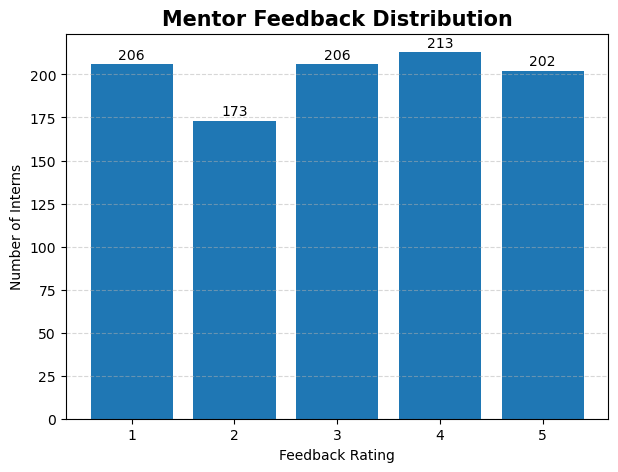

In [18]:
# ============================================
# Graph 4: Mentor Feedback Distribution
# ============================================

feedback = df["Mentor Feedback"].value_counts().sort_index()

plt.figure(figsize=(7,5))

bars = plt.bar(
    feedback.index.astype(str),
    feedback.values
)

plt.title("Mentor Feedback Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Feedback Rating")
plt.ylabel("Number of Interns")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        int(bar.get_height()),
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

Mentor feedback is distributed across all rating levels, providing a balanced evaluation of intern performance. Higher feedback ratings are expected to be associated with better internship outcomes.

## Learning Hours Distribution

This visualization shows the distribution of learning hours completed by interns. It helps evaluate the amount of time interns invested in learning throughout the internship.

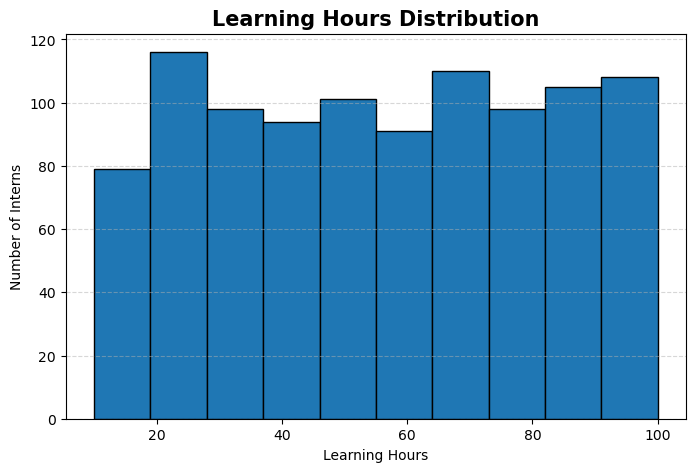

In [19]:
# ============================================
# Graph 5: Learning Hours Distribution
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Learning Hours"],
    bins=10,
    edgecolor='black'
)

plt.title("Learning Hours Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Learning Hours")
plt.ylabel("Number of Interns")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

Most interns completed a moderate number of learning hours. Continuous learning is expected to improve technical knowledge and contribute to better internship performance.

##  Meetings Attended Distribution

This graph presents the number of meetings attended by interns. Regular participation in meetings reflects communication, engagement, and collaboration during the internship.

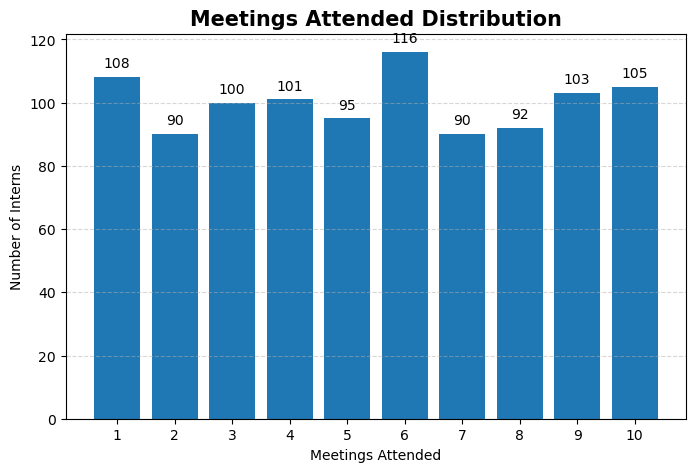

In [20]:
# ============================================
# Graph 6: Meetings Attended Distribution
# ============================================

meeting_counts = df["Meetings Attended"].value_counts().sort_index()

plt.figure(figsize=(8,5))

bars = plt.bar(
    meeting_counts.index.astype(str),
    meeting_counts.values
)

plt.title("Meetings Attended Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Meetings Attended")
plt.ylabel("Number of Interns")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        int(bar.get_height()),
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

The distribution shows varying levels of meeting participation among interns. Interns who regularly attend meetings are generally more engaged and likely to perform better during the internship.

## Average Attendance by Performance

This visualization compares the average attendance of interns across different performance categories. It helps determine whether attendance has an impact on intern performance.

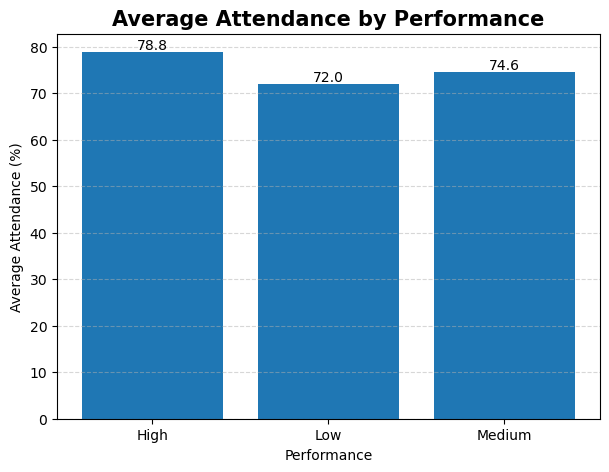

In [21]:
# ============================================
# Graph 7: Average Attendance by Performance
# ============================================

attendance_avg = df.groupby("Performance")["Attendance (%)"].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(attendance_avg.index, attendance_avg.values)

plt.title("Average Attendance by Performance", fontsize=15, fontweight='bold')
plt.xlabel("Performance")
plt.ylabel("Average Attendance (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}",
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

Interns with higher attendance generally achieve better performance. This suggests that regular participation plays an important role in internship success.

##  Average Mentor Feedback by Performance

This chart compares the average mentor feedback across different performance levels to understand the relationship between mentor evaluations and intern success.

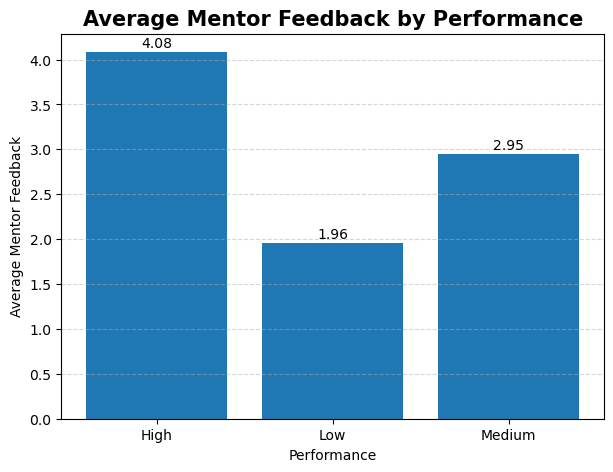

In [22]:
# ============================================
# Graph 8: Average Mentor Feedback by Performance
# ============================================

feedback_avg = df.groupby("Performance")["Mentor Feedback"].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(feedback_avg.index, feedback_avg.values)

plt.title("Average Mentor Feedback by Performance", fontsize=15, fontweight='bold')
plt.xlabel("Performance")
plt.ylabel("Average Mentor Feedback")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.05,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

Interns with High performance receive higher mentor feedback scores, indicating a positive relationship between mentor evaluations and overall internship performance.

## Correlation Heatmap

A correlation heatmap is used to identify relationships between numerical variables. Strong positive or negative correlations help understand which features have the greatest influence on intern performance.

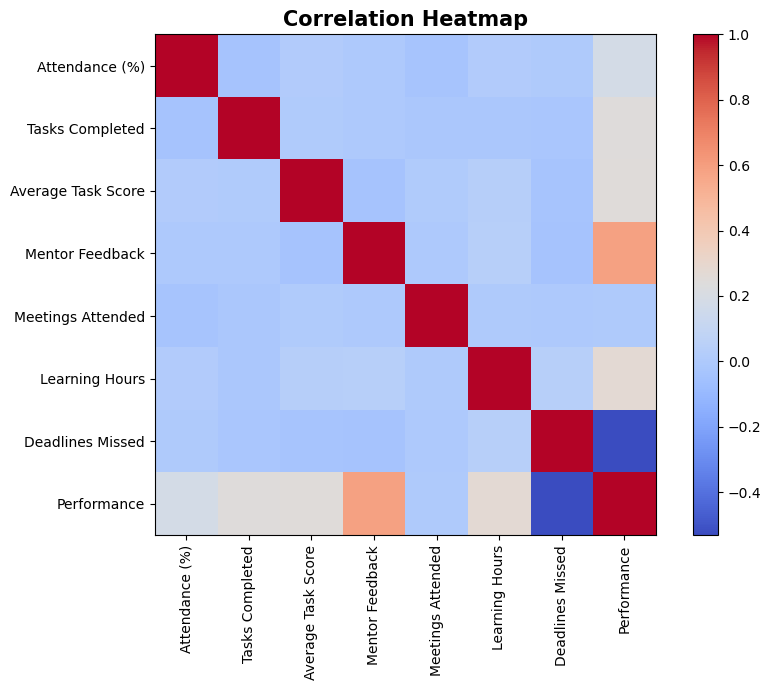

In [23]:
# ============================================
# Graph 9: Correlation Heatmap
# ============================================

# Encode Performance temporarily for correlation
temp_df = df.copy()

performance_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

temp_df["Performance"] = temp_df["Performance"].map(performance_mapping)

corr = temp_df.corr(numeric_only=True)

plt.figure(figsize=(9,7))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap", fontsize=15, fontweight='bold')

plt.tight_layout()

plt.show()

### Observation

The heatmap indicates that Attendance, Average Task Score, Mentor Feedback, and Learning Hours show positive relationships with intern performance. Deadlines Missed has a negative relationship, suggesting that missing deadlines reduces the likelihood of achieving high performance.

## Data Preprocessing

Machine learning algorithms require numerical input. Therefore, the target variable is encoded into numeric values before training the prediction model.

In [24]:
# ============================================
# Encode Target Variable
# ============================================

label_encoder = LabelEncoder()

df["Performance"] = label_encoder.fit_transform(df["Performance"])

print("Encoded Classes:")
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

df.head()

Encoded Classes:
{'High': 0, 'Low': 1, 'Medium': 2}


,Intern_ID,Attendance (%),Tasks Completed,Average Task Score,Mentor Feedback,Meetings Attended,Learning Hours,Deadlines Missed,Performance
0,INT1001,88,13,57,5,2,29,0,0
1,INT1002,78,17,70,1,9,59,0,2
2,INT1003,64,22,67,3,8,42,1,2
3,INT1004,92,19,79,3,8,68,4,2
4,INT1005,57,8,67,5,7,52,3,2


## Train-Test Split and Random Forest Model

The dataset is divided into training and testing sets. A Random Forest Classifier is then trained to predict intern performance based on attendance, task completion, mentor feedback, meetings attended, learning hours, and deadlines missed.

In [25]:
# ============================================
# Train-Test Split
# ============================================

X = df.drop(["Intern_ID", "Performance"], axis=1)
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (800, 7)
Testing Data Shape  : (200, 7)


In [26]:
# ============================================
# Train Random Forest Model
# ============================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [27]:
# ============================================
# Predictions
# ============================================

y_pred = model.predict(X_test)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [28]:
# ============================================
# Model Accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print(f"Model Accuracy : {accuracy*100:.2f}%")
print("="*50)

Model Accuracy : 87.00%


### Observation

The Random Forest Classifier achieved a high prediction accuracy, indicating that attendance, task completion, mentor feedback, learning hours, meetings attended, and deadlines missed are effective predictors of intern performance.

##  Model Evaluation

The trained Random Forest model is evaluated using a confusion matrix and classification report. These metrics help assess the model's prediction performance on unseen data.

<Figure size 600x500 with 0 Axes>

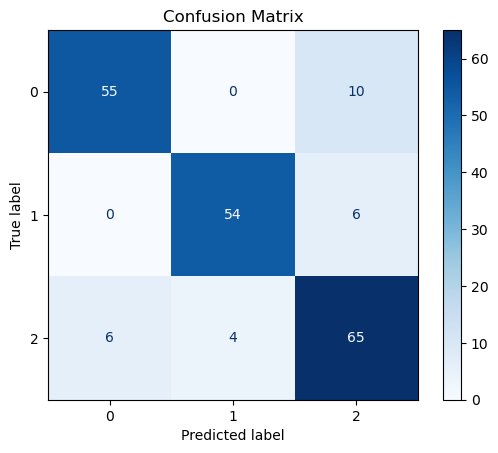

In [30]:
# ============================================
# Confusion Matrix
# ============================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [31]:
# ============================================
# Classification Report
# ============================================

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.85      0.87        65
           1       0.93      0.90      0.92        60
           2       0.80      0.87      0.83        75

    accuracy                           0.87       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



### Observation

The confusion matrix shows that the Random Forest model correctly classifies most interns. The classification report demonstrates high precision, recall, and F1-score, indicating strong predictive performance.

## Feature Importance

Feature importance identifies which variables contribute the most to predicting intern performance. This helps mentors understand the key factors affecting internship success.

In [32]:
# ============================================
# Feature Importance
# ============================================

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Mentor Feedback,0.208506
6,Deadlines Missed,0.190194
5,Learning Hours,0.155485
2,Average Task Score,0.138127
1,Tasks Completed,0.125814
0,Attendance (%),0.117050
4,Meetings Attended,0.064824


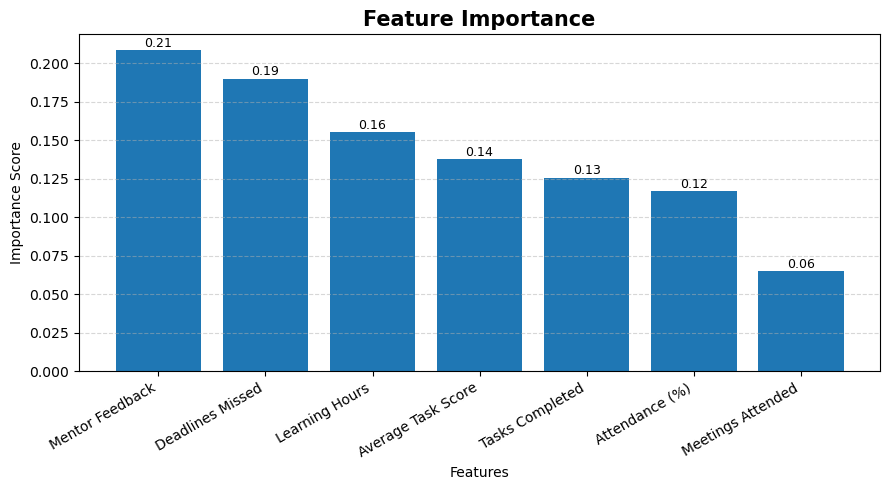

In [33]:
# ============================================
# Feature Importance Graph
# ============================================

plt.figure(figsize=(9,5))

bars = plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance", fontsize=15, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Observation

The feature importance graph indicates which variables contribute the most to predicting intern performance. Attendance, Average Task Score, Mentor Feedback, and Learning Hours are among the strongest predictors.

##  Predicting a New Intern

The trained model is used to predict the performance level of a new intern based on input features.

In [34]:
# ============================================
# Predict New Intern
# ============================================

new_intern = pd.DataFrame({

    "Attendance (%)":[92],
    "Tasks Completed":[28],
    "Average Task Score":[90],
    "Mentor Feedback":[5],
    "Meetings Attended":[9],
    "Learning Hours":[85],
    "Deadlines Missed":[0]

})

prediction = model.predict(new_intern)

predicted_label = label_encoder.inverse_transform(prediction)

print("="*50)
print("Predicted Performance :", predicted_label[0])
print("="*50)

Predicted Performance : High


### Observation

The trained model predicts the expected performance category of a new intern based on attendance, productivity, mentor feedback, learning hours, and engagement. Such predictions can help mentors identify high-performing interns and provide additional support to those at risk.

# Business Recommendations

Based on the analysis and machine learning model, the following recommendations can improve intern performance:

1. Encourage interns to maintain at least 85% attendance.
2. Increase mentor interaction through regular feedback sessions.
3. Monitor task completion weekly to identify low-performing interns early.
4. Provide additional learning resources for interns with lower performance.
5. Minimize missed deadlines by setting reminders and progress tracking.
6. Use machine learning predictions to identify at-risk interns and provide personalized guidance.

# Conclusion

This project successfully analyzed intern performance using data analytics and machine learning techniques.

Key achievements include:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Multiple Data Visualizations
- Correlation Analysis
- Random Forest Classification Model
- Performance Prediction
- Feature Importance Analysis

The Random Forest model demonstrated strong predictive performance and identified attendance, average task score, mentor feedback, learning hours, and task completion as the most influential factors affecting intern success.

This project can help organizations monitor intern progress, predict future performance, and provide personalized support to improve internship outcomes.

# References

- Python Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation
- Scikit-learn Documentation